## CICIOT2023 XGBOOST

In [15]:
import os
import kagglehub
import pandas as pd
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime

In [16]:
os.environ["KAGGLEHUB_CACHE"] = "D:\\kaggle_cache"

# 自動下載資料集
path = kagglehub.dataset_download("madhavmalhotra/unb-cic-iot-dataset")

print(f"資料集已下載至: {path}")

# 找到 CICIoT2023 資料夾
target_path = os.path.join(
    path,
    "wataiData",
    "csv",
    "CICIoT2023"
)

# 讀取所有 CSV
all_files = glob(os.path.join(target_path, "*.csv"))

print(f"找到的 CSV 檔案數量: {len(all_files)}\n")

if len(all_files) == 0:
    print("【錯誤】找不到檔案!")
else:
    df_list = []
    
    for i, filename in enumerate(all_files, 1):
        print(f"[{i}/{len(all_files)}] 正在讀取: {os.path.basename(filename)}")
        temp_df = pd.read_csv(filename)
        df_list.append(temp_df)
    
    # 合併所有資料
    df = pd.concat(df_list, axis=0, ignore_index=True)
    
    print(f"\n{'='*60}")
    print(f"合併成功!")
    print(f"{'='*60}")
    print(f"總資料列數: {len(df):,}")
    print(f"特徵數量: {df.shape[1]}")
    print(f"原始標籤種類: {df['label'].nunique()}")
    
    # 釋放記憶體
    del df_list

資料集已下載至: D:\kaggle_cache\datasets\madhavmalhotra\unb-cic-iot-dataset\versions\1
找到的 CSV 檔案數量: 169

[1/169] 正在讀取: part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[2/169] 正在讀取: part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[3/169] 正在讀取: part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[4/169] 正在讀取: part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[5/169] 正在讀取: part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[6/169] 正在讀取: part-00005-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[7/169] 正在讀取: part-00006-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[8/169] 正在讀取: part-00007-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[9/169] 正在讀取: part-00008-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[10/169] 正在讀取: part-00009-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[11/169] 正在讀取: part-00010-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[12/169] 正在讀取: part-00011-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
[13/169] 正在讀取: part-00012-363d1ba3-8ab5-4f96-b

In [17]:
# 2. 標籤映射 (根據 CIC-IoT-2023 特性)
# ============================================

print(f"\n{'='*60}")
print("執行標籤映射")
print(f"{'='*60}")

mapping = {
    # /***  DDoS 類別   ***/ 
    'DDoS-ACK_Fragmentation': 'DDoS',
    'DDoS-UDP_Flood': 'DDoS',
    'DDoS-SlowLoris': 'DDoS',
    'DDoS-ICMP_Flood': 'DDoS',
    'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS',
    'DDoS-HTTP_Flood': 'DDoS',
    'DDoS-UDP_Fragmentation': 'DDoS',
    'DDoS-TCP_Flood': 'DDoS',
    'DDoS-SYN_Flood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS',
    'DDoS-ICMP_Fragmentation': 'DDoS',
    
    # /***  Brute Force 類別   ***/
    'DictionaryBruteForce': 'Brute Force',
    
    # /***  Spoofing 類別   ***/
    'MITM-ArpSpoofing': 'Spoofing',
    'DNS_Spoofing': 'Spoofing',
    
    # /***  DoS 類別   ***/
    'DoS-TCP_Flood': 'DoS',
    'DoS-HTTP_Flood': 'DoS',
    'DoS-SYN_Flood': 'DoS',
    'DoS-UDP_Flood': 'DoS',
    
    # /***  Recon 類別   ***/
    'Recon-HostDiscovery': 'Recon',
    'Recon-OSScan': 'Recon',
    'Recon-PortScan': 'Recon',
    'Recon-PingSweep': 'Recon',
    'VulnerabilityScan': 'Recon',
    
    # /***  Web-based 類別   ***/
    'SqlInjection': 'Web-based',
    'XSS': 'Web-based',
    'CommandInjection': 'Web-based',
    'Backdoor_Malware': 'Web-based',
    'Uploading_Attack': 'Web-based',
    'BrowserHijacking': 'Web-based',
    
    # /***  Mirai 類別   ***/
    'Mirai-greeth_flood': 'Mirai',
    'Mirai-udpplain': 'Mirai',
    'Mirai-greip_flood': 'Mirai',
    
    # /***  Benign 類別   ***/
    'BenignTraffic': 'Benign',
}

# 執行映射
df['label_category'] = df['label'].map(mapping)

# 檢查未映射的標籤
unmapped = df[df['label_category'].isna()]
if len(unmapped) > 0:
    print(f"\n⚠️ 發現 {len(unmapped):,} 筆未映射的資料:")
    print(unmapped['label'].value_counts())
    print("\n這些資料將被移除")

# 刪除未映射的資料
df.dropna(subset=['label_category'], inplace=True)

print(f"\n映射後的類別分佈:")
print(df['label_category'].value_counts())
print(f"\n總類別數: {df['label_category'].nunique()}")


執行標籤映射

映射後的類別分佈:
label_category
DDoS           33984560
DoS             8090738
Mirai           2634124
Benign          1098195
Spoofing         486504
Recon            354565
Web-based         24829
Brute Force       13064
Name: count, dtype: int64

總類別數: 8


In [18]:
# 3. 溫和的資料清洗策略
# ============================================

print(f"\n{'='*60}")
print("執行溫和的資料清洗")
print(f"{'='*60}")

print(f"清洗前資料筆數: {len(df):,}")

# 步驟 1: 處理 inf 值 → 替換為 NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print("✓ 已將 inf 值替換為 NaN")

# 步驟 2: 計算每行的缺失比例
missing_ratio = df.isnull().sum(axis=1) / df.shape[1]

# 步驟 3: 只刪除缺失值超過 50% 的行
threshold = 0.5
df_cleaned = df[missing_ratio <= threshold].copy()
removed_rows = len(df) - len(df_cleaned)

print(f"✓ 刪除缺失值 > {threshold*100}% 的行: {removed_rows:,} 筆")
print(f"  保留率: {len(df_cleaned)/len(df)*100:.2f}%")

# 步驟 4: 對剩餘的缺失值填充 (用中位數)
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].median())
print(f"✓ 已用中位數填充剩餘缺失值")

# 更新 df
df = df_cleaned
del df_cleaned

print(f"\n清洗後資料筆數: {len(df):,}")
print(f"清洗後類別分佈:")
print(df['label_category'].value_counts())


執行溫和的資料清洗
清洗前資料筆數: 46,686,579
✓ 已將 inf 值替換為 NaN
✓ 刪除缺失值 > 50.0% 的行: 0 筆
  保留率: 100.00%
✓ 已用中位數填充剩餘缺失值

清洗後資料筆數: 46,686,579
清洗後類別分佈:
label_category
DDoS           33984560
DoS             8090738
Mirai           2634124
Benign          1098195
Spoofing         486504
Recon            354565
Web-based         24829
Brute Force       13064
Name: count, dtype: int64


In [19]:
# 4. 準備特徵與標籤
# ============================================

print(f"\n{'='*60}")
print("準備訓練資料")
print(f"{'='*60}")

# 分離特徵和標籤
X = df.drop(['label', 'label_category'], axis=1)
y = df['label_category']

# 保存特徵名稱
feature_names = X.columns.tolist()
print(f"特徵數量: {len(feature_names)}")

# 使用 LabelEncoder 將類別標籤轉為數字
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"類別對應:")
for i, class_name in enumerate(le.classes_):
    count = (y_encoded == i).sum()
    print(f"  {i}: {class_name:15s} - {count:,} 筆")


準備訓練資料


特徵數量: 46
類別對應:
  0: Benign          - 1,098,195 筆
  1: Brute Force     - 13,064 筆
  2: DDoS            - 33,984,560 筆
  3: DoS             - 8,090,738 筆
  4: Mirai           - 2,634,124 筆
  5: Recon           - 354,565 筆
  6: Spoofing        - 486,504 筆
  7: Web-based       - 24,829 筆


In [20]:
# 5. 資料切割 (70% 訓練, 20% 測試, 10% 驗證)
# ============================================

print(f"\n{'='*60}")
print("切割資料集")
print(f"{'='*60}")

# 先切出 70% 訓練集,剩餘 30% 給 (測試+驗證)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_encoded
)

# 再從 30% 中切出 2/3 給測試集 (即總體的 20%),1/3 給驗證集 (即總體的 10%)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.3333, 
    random_state=42, 
    stratify=y_temp
)

print(f"訓練集: {X_train.shape[0]:,} 筆 ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"測試集: {X_test.shape[0]:,} 筆 ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"驗證集: {X_val.shape[0]:,} 筆 ({X_val.shape[0]/len(df)*100:.1f}%)")

# 釋放記憶體
del df, X, y, X_temp, y_temp


切割資料集
訓練集: 32,680,605 筆 (70.0%)
測試集: 9,337,782 筆 (20.0%)
驗證集: 4,668,192 筆 (10.0%)


In [21]:
# 6. 建立並訓練 XGBoost 模型
# ============================================

print(f"\n{'='*60}")
print("建立 XGBoost 模型")
print(f"{'='*60}")

# XGBoost 參數設定
xgb_params = {
    'max_depth': 10,              # 樹的最大深度 (與 Random Forest 的 20 相比較保守)
    'learning_rate': 0.1,         # 學習率
    'n_estimators': 100,          # 樹的數量 (與 Random Forest 一致)
    'objective': 'multi:softmax', # 多分類問題
    'num_class': len(le.classes_),# 類別數量
    'n_jobs': -1,                 # 使用所有 CPU 核心
    'random_state': 42,
    'eval_metric': 'mlogloss',    # 評估指標
    'subsample': 0.8,             # 每棵樹使用 80% 的樣本
    'colsample_bytree': 0.8,      # 每棵樹使用 80% 的特徵
    'verbosity': 1                # 顯示訓練進度
}

# 建立模型
xgb_model = xgb.XGBClassifier(**xgb_params)

print("模型參數:")
for key, value in xgb_params.items():
    print(f"  {key}: {value}")

# 開始訓練
print(f"\n開始訓練 XGBoost 模型...")
print("(這可能需要一些時間,請耐心等待...)\n")

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

print("\n✓ 模型訓練完成!")



建立 XGBoost 模型
模型參數:
  max_depth: 10
  learning_rate: 0.1
  n_estimators: 100
  objective: multi:softmax
  num_class: 8
  n_jobs: -1
  random_state: 42
  eval_metric: mlogloss
  subsample: 0.8
  colsample_bytree: 0.8
  verbosity: 1

開始訓練 XGBoost 模型...
(這可能需要一些時間,請耐心等待...)

[0]	validation_0-mlogloss:0.71125
[1]	validation_0-mlogloss:0.62249
[2]	validation_0-mlogloss:0.54065
[3]	validation_0-mlogloss:0.47546
[4]	validation_0-mlogloss:0.42967
[5]	validation_0-mlogloss:0.38989
[6]	validation_0-mlogloss:0.36303
[7]	validation_0-mlogloss:0.33165
[8]	validation_0-mlogloss:0.29719
[9]	validation_0-mlogloss:0.26707
[10]	validation_0-mlogloss:0.24063
[11]	validation_0-mlogloss:0.21730
[12]	validation_0-mlogloss:0.19657
[13]	validation_0-mlogloss:0.17815
[14]	validation_0-mlogloss:0.16174
[15]	validation_0-mlogloss:0.14972
[16]	validation_0-mlogloss:0.13878
[17]	validation_0-mlogloss:0.12652
[18]	validation_0-mlogloss:0.11553
[19]	validation_0-mlogloss:0.10559
[20]	validation_0-mlogloss:0.09847
[

In [22]:
# 7. 模型評估
# ============================================

print(f"\n{'='*60}")
print("模型評估")
print(f"{'='*60}")

# 驗證集評估
y_val_pred = xgb_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"\n=== 驗證集表現 ===")
print(f"準確率: {val_accuracy:.4f}")

# 測試集評估
y_test_pred = xgb_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n=== 測試集表現 ===")
print(f"準確率: {test_accuracy:.4f}")

# 詳細分類報告
print(f"\n=== 詳細分類報告 (測試集) ===")
print(classification_report(
    y_test, y_test_pred, 
    target_names=le.classes_,
    digits=4
))



模型評估

=== 驗證集表現 ===
準確率: 0.9951

=== 測試集表現 ===
準確率: 0.9951

=== 詳細分類報告 (測試集) ===
              precision    recall  f1-score   support

      Benign     0.9025    0.9696    0.9348    219650
 Brute Force     0.6256    0.2935    0.3996      2613
        DDoS     0.9999    0.9999    0.9999   6797251
         DoS     0.9998    0.9995    0.9996   1618228
       Mirai     1.0000    0.9999    1.0000    526851
       Recon     0.8623    0.7696    0.8133     70917
    Spoofing     0.8724    0.8377    0.8547     97306
   Web-based     0.6613    0.2056    0.3137      4966

    accuracy                         0.9951   9337782
   macro avg     0.8655    0.7594    0.7894   9337782
weighted avg     0.9949    0.9951    0.9949   9337782




繪製混淆矩陣


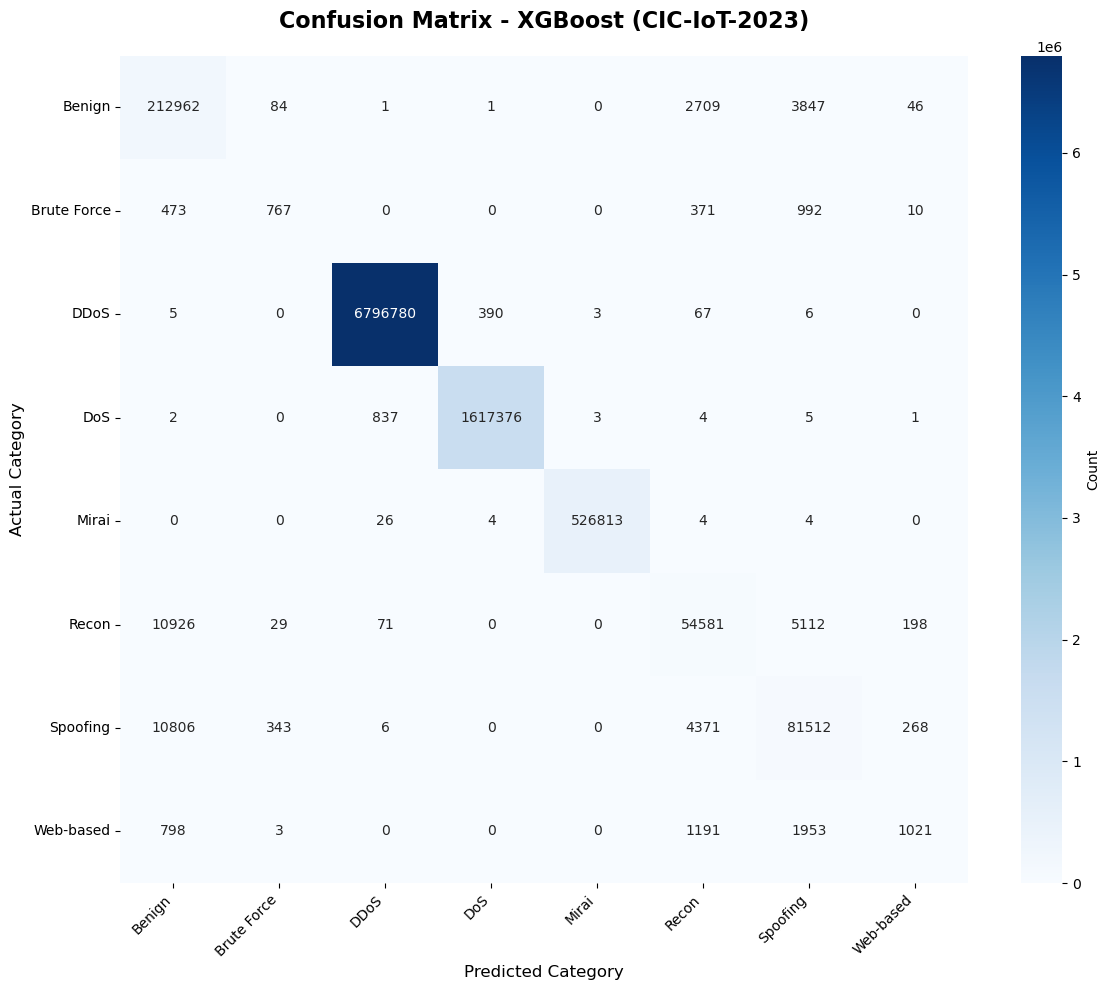

In [32]:
# 8. 繪製混淆矩陣
# ============================================

print(f"\n{'='*60}")
print("繪製混淆矩陣")
print(f"{'='*60}")

def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix'):
    """繪製混淆矩陣"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Count'})
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Actual Category', fontsize=12)
    plt.xlabel('Predicted Category', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(r"C:\Users\pccu1\Desktop\project-model\XGBOOST\confusion_matrix.png")
    plt.show()

# 繪製混淆矩陣
plot_confusion_matrix(
    y_test, y_test_pred, 
    le.classes_,
    title='Confusion Matrix - XGBoost (CIC-IoT-2023)'
)



特徵重要性分析

=== Top 20 重要特徵 ===
 1. IAT                                : 0.344880
 2. Min                                : 0.097345
 3. Weight                             : 0.083544
 4. ICMP                               : 0.045120
 5. rst_count                          : 0.043603
 6. fin_flag_number                    : 0.039651
 7. Magnitue                           : 0.038435
 8. Number                             : 0.029063
 9. psh_flag_number                    : 0.027883
10. UDP                                : 0.027023
11. Tot size                           : 0.022753
12. rst_flag_number                    : 0.020807
13. Variance                           : 0.020155
14. AVG                                : 0.013857
15. SSH                                : 0.013222
16. Tot sum                            : 0.011562
17. syn_flag_number                    : 0.011176
18. flow_duration                      : 0.010469
19. fin_count                          : 0.010105
20. urg_count       

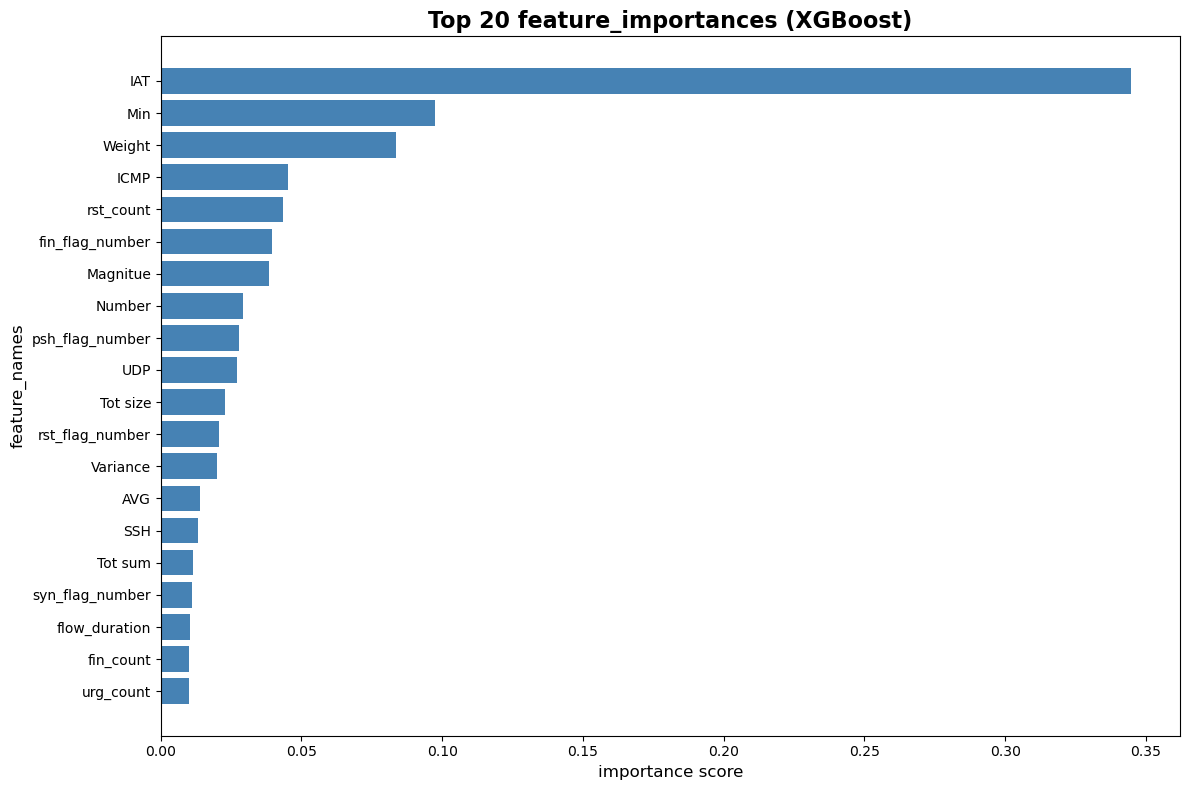

In [33]:
# 9. 特徵重要性分析
# ============================================

print(f"\n{'='*60}")
print("特徵重要性分析")
print(f"{'='*60}")

# 獲取特徵重要性
feature_importance = xgb_model.feature_importances_
feature_importance_dict = dict(zip(feature_names, feature_importance))

# 排序並顯示 Top 20
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

print("\n=== Top 20 重要特徵 ===")
for rank, (feature, importance) in enumerate(sorted_features[:20], 1):
    print(f"{rank:2d}. {feature:35s}: {importance:.6f}")

# 繪製特徵重要性圖
def plot_feature_importance(model, feature_names, top_n=20):
    """繪製特徵重要性圖表"""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]
    
    plt.figure(figsize=(12, 8))
    plt.title(f'Top {top_n} feature_importances (XGBoost)', fontsize=16, fontweight='bold')
    plt.barh(range(top_n), importances[indices], color='steelblue')
    plt.yticks(range(top_n), [feature_names[i] for i in indices])
    plt.xlabel('importance score', fontsize=12)
    plt.ylabel('feature_names', fontsize=12)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(r"C:\Users\pccu1\Desktop\project-model\XGBOOST\Top20_feature_importances.png")
    plt.show()

plot_feature_importance(xgb_model, feature_names, top_n=20)

In [25]:
# 10. 保存完整模型套件 (含驗證集數據快照)
# ============================================

print(f"\n{'='*60}")
print("保存模型 (含數據快照)")
print(f"{'='*60}")

def save_complete_xgboost_model(model, le, feature_names, X_train, y_train, 
                                X_test, y_test, y_test_pred, 
                                X_val, y_val, save_dir='models'):
    """
    保存完整的 XGBoost 模型及所有相關資訊，並包含驗證集數據快照供未來對照。
    """
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # 計算評估指標
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # 建立完整的模型套件
    model_package = {
        'model': model,
        'label_encoder': le,
        'feature_names': feature_names,
        # --- 新增：驗證集數據快照 ---
        'data_snapshot': {
            'X_val': X_val,               # 驗證集特徵數據
            'y_val_encoded': y_val,       # 驗證集數字標籤
            'y_val_labels': le.inverse_transform(y_val), # 驗證集原始文字標籤
            'description': "此快照包含 10% 的原始數據，用於未來模型重新驗證與對照。"
        },
        'config': {
            'model_type': 'XGBoost',
            'max_depth': model.max_depth,
            'learning_rate': model.learning_rate,
            'n_estimators': model.n_estimators,
            'random_state': model.random_state,
        },
        'training_info': {
            'train_samples': X_train.shape[0],
            'test_samples': X_test.shape[0],
            'val_samples': X_val.shape[0],
            'n_features': X_train.shape[1],
            'n_classes': len(le.classes_),
        },
        'performance': {
            'test_accuracy': test_accuracy,
            'classification_report': classification_report(
                y_test, y_test_pred, 
                target_names=le.classes_,
                output_dict=True
            )
        },
        'feature_importance': dict(zip(feature_names, model.feature_importances_)),
        'timestamp': timestamp
    }
    
    # 保存完整套件
    package_path = os.path.join(save_dir, f'xgboost_complete_{timestamp}.joblib')
    joblib.dump(model_package, package_path)
    print(f"✓ 完整模型套件已保存至: {package_path}")
    print(f"  (已包含 {X_val.shape[0]:,} 筆驗證集數據快照)")
    
    # 保存純文字報告 (邏輯與原本相同)
    report_path = os.path.join(save_dir, f'xgboost_report_{timestamp}.txt')
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("=" * 60 + "\n")
        f.write("XGBoost IoT 攻擊分類模型訓練報告 (含數據快照)\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"訓練時間: {timestamp}\n")
        f.write(f"測試集準確率: {test_accuracy:.4f}\n")
        f.write(f"驗證集樣本數: {X_val.shape[0]:,} (已封裝於 joblib 檔中)\n")
        # ... (其餘報告內容可保持不變)
    
    return package_path, report_path

# 執行保存 (注意：多傳入了 X_val 和 y_val)
package_path, report_path = save_complete_xgboost_model(
    xgb_model, le, feature_names,
    X_train, y_train, 
    X_test, y_test, y_test_pred,
    X_val, y_val, 
    save_dir='models'
)


保存模型 (含數據快照)
✓ 完整模型套件已保存至: models\xgboost_complete_20260512_115134.joblib
  (已包含 4,668,192 筆驗證集數據快照)
